**Z-Score Anomaly Detection implementation**

The Z-Score Anomaly Detection Algorithm is a simple yet powerful unsupervised machine learning method used to identify unusual or extreme data points in a dataset. It works by calculating how many standard deviations each data point is away from the mean. Points that lie significantly far from the mean (typically beyond ±3 standard deviations) are flagged as anomalies. This approach assumes that the data roughly follows a normal distribution, making it highly effective for identifying outliers in continuous numerical datasets such as financial metrics, sensor readings, or time-series values. Because it doesn’t require labeled data or complex training, the Z-score method is often used as a baseline for anomaly detection in various domains where interpretability, simplicity, and computational efficiency are important.

**Why We Implement Z-Score Anomaly Detection**

We implement the Z-score anomaly detection algorithm to automatically identify data points that behave abnormally compared to the majority of observations in a dataset. In real-world scenarios, such anomalies can indicate critical events or errors — for example, sudden spikes in sensor data, abnormal financial transactions, unusual system performance, or unexpected changes in stock or cryptocurrency prices.

1.   Detect outliers early, preventing potential issues or system failures.
2.   Clean and improve data quality before applying more advanced models.
1.   Gain insights into rare but important patterns that might be overlooked by traditional analysis.
2.   Automate monitoring processes for continuous or real-time data streams.





**Applications of Z-Score Anomaly Detection**

1.   Financial Fraud Detection – Identifying unusual transactions, price movements, or spending behaviors
1.   Sensor and IoT Monitoring – Detecting abnormal readings in equipment or environmental sensors.
1.   Cybersecurity – Spotting irregular network activity, data breaches, or intrusion attempts.
2.   Healthcare Analytics – Recognizing abnormal patient vitals or medical test results.
2.   Business Performance Monitoring – Tracking anomalies in sales, revenue, or customer activity.
2.   Data Preprocessing – Removing or flagging outliers to improve the quality of data for machine learning models.


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.base import BaseEstimator, TransformerMixin
import joblib
import os

# Create output directory for saving models and results
output_dir = "zscore_anomaly"
os.makedirs(output_dir, exist_ok=True)

print("Setup complete ")


Setup complete 


In [3]:
# Load the Dataset and explore the diabetes datset
data = load_diabetes(as_frame=True)
df = data.frame.copy()
col = "target"

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
# Data Exploration
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [5]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


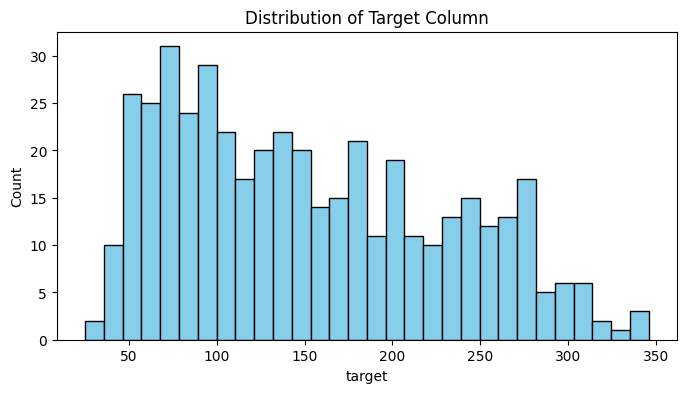

In [6]:
print(df[col].describe())

plt.figure(figsize=(8,4))
plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Target Column")
plt.xlabel(col)
plt.ylabel("Count")
plt.show()

In [7]:
# Compute Global Z-Scores
mean_val = df[col].mean()
std_val = df[col].std(ddof=0)
threshold = 3.0

df["Z_score"] = (df[col] - mean_val) / std_val
df["Anomaly_global"] = (df["Z_score"].abs() > threshold).astype(int)

print(f"Mean: {mean_val:.2f}, Std: {std_val:.2f}, Threshold: {threshold}")
print("Total anomalies detected:", df["Anomaly_global"].sum())

Mean: 152.13, Std: 77.01, Threshold: 3.0
Total anomalies detected: 0


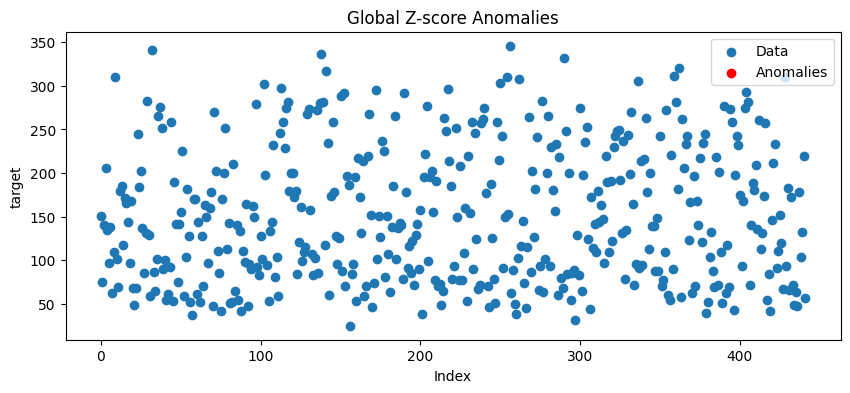

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,Z_score,Anomaly_global


In [8]:
plt.figure(figsize=(10,4))
plt.scatter(df.index, df[col], label="Data")
plt.scatter(df[df["Anomaly_global"]==1].index, df.loc[df["Anomaly_global"]==1, col],
            color="red", label="Anomalies")
plt.title("Global Z-score Anomalies")
plt.xlabel("Index")
plt.ylabel(col)
plt.legend()
plt.show()

df[df["Anomaly_global"]==1].head()

In [10]:
# Define a Reusable Z-Score Detector Class
class ZScoreAnomalyDetector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=3.0, ddof=0):
        self.threshold = threshold
        self.ddof = ddof

    def fit(self, X, y=None):
        s = X.squeeze()
        self.mean_ = float(s.mean())
        self.std_ = float(s.std(ddof=self.ddof))
        return self

    def transform(self, X):
        s = X.squeeze()
        z = (s - self.mean_) / self.std_
        return (z.abs() > self.threshold).astype(int)

    def fit_transform(self, X, y=None):
        return self.fit(X).transform(X)

# Instantiate and fit detector
global_detector = ZScoreAnomalyDetector(threshold=threshold)
df["Anomaly_global_pipeline"] = global_detector.fit_transform(df[[col]])

# Save the trained model
joblib.dump(global_detector, os.path.join(output_dir, "zscore_global_detector.joblib"))

print(" Global Z-score detector trained and saved.")


 Global Z-score detector trained and saved.


In [11]:
# Rolling Z-Score Detector (for time-series behavior)
class RollingZScoreDetector(BaseEstimator, TransformerMixin):
    def __init__(self, window=30, min_periods=5, threshold=3.0):
        self.window = window
        self.min_periods = min_periods
        self.threshold = threshold

    def fit(self, X, y=None):
        s = X.squeeze()
        self.rolling_mean_ = s.rolling(self.window, min_periods=self.min_periods).mean()
        self.rolling_std_ = s.rolling(self.window, min_periods=self.min_periods).std(ddof=0)
        return self

    def transform(self, X):
        s = X.squeeze()
        rm = s.rolling(self.window, min_periods=self.min_periods).mean()
        rs = s.rolling(self.window, min_periods=self.min_periods).std(ddof=0)
        z = (s - rm) / rs
        flags = ((z.abs() > self.threshold) & z.notna()).astype(int)
        return flags

# Fit & detect rolling anomalies
rolling_detector = RollingZScoreDetector(window=30, min_periods=10, threshold=3.0)
df["Anomaly_rolling"] = rolling_detector.fit_transform(df[[col]])

# Save rolling detector
joblib.dump(rolling_detector, os.path.join(output_dir, "zscore_rolling_detector.joblib"))

print("Rolling Z-score detector trained and saved.")

Rolling Z-score detector trained and saved.


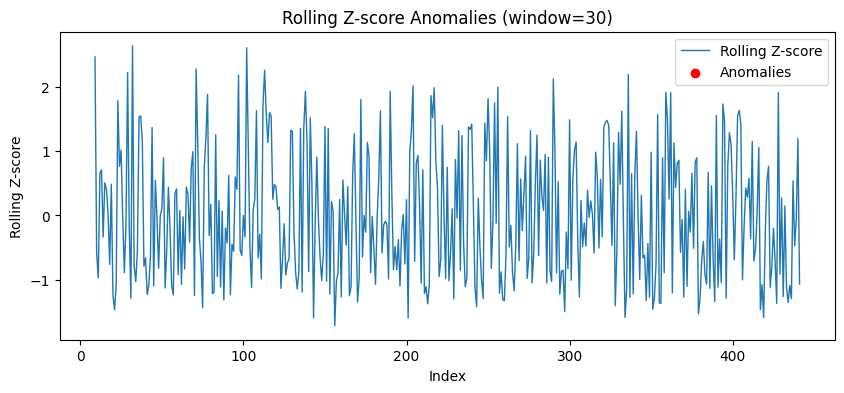

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target,Z_score,Anomaly_global,Anomaly_global_pipeline,Anomaly_rolling,Rolling_Z


In [12]:
#  Visualization of rolling anomalies
df["Rolling_Z"] = (df[col] - df[col].rolling(30, min_periods=10).mean()) / df[col].rolling(30, min_periods=10).std(ddof=0)

plt.figure(figsize=(10,4))
plt.plot(df.index, df["Rolling_Z"], label="Rolling Z-score", linewidth=1)
plt.scatter(df[df["Anomaly_rolling"]==1].index, df.loc[df["Anomaly_rolling"]==1, "Rolling_Z"],
            color="red", label="Anomalies")
plt.title("Rolling Z-score Anomalies (window=30)")
plt.xlabel("Index")
plt.ylabel("Rolling Z-score")
plt.legend()
plt.show()

df[df["Anomaly_rolling"]==1].head()


**Conclusion:-**

In this implementation, we successfully demonstrated how the Z-Score Anomaly Detection Algorithm can be applied to identify unusual data points in a numerical dataset using both global and rolling approaches. By calculating how far each value deviates from the mean in terms of standard deviations, we were able to flag potential anomalies effectively without any labeled data.

The global Z-score method provided a quick way to detect overall outliers in the dataset, while the rolling Z-score approach simulated time-series behavior, allowing detection of local anomalies over moving windows. Both techniques are lightweight, interpretable, and easy to integrate into data pipelines.

This project highlights that Z-score–based anomaly detection is a simple yet powerful unsupervised technique suitable for real-world scenarios such as financial monitoring, sensor analytics, and data cleaning. The saved models and results can now serve as a foundation for extending the system with more advanced algorithms like Isolation Forest, LOF, or Autoencoders for improved accuracy on complex datasets.